# Analytical Derivation of the LPF-Modulation-Demodulation Chain

We study the continuous-time random process chain

$$
\eta(t) \xrightarrow{\text{LPF } H(\omega)} x(t) \xrightarrow{\times \cos(\omega_0 t)} y(t) \xrightarrow{\times \cos(\omega_0 t)} z(t) \xrightarrow{\text{LPF } H(\omega)} u(t),
$$

with an ideal low-pass filter

$$
H(\omega) =
\begin{cases}
1, & |\omega| \leq \Omega, \\
0, & |\omega| > \Omega,
\end{cases}
$$

and carrier frequency $\omega_0 = k\Omega$ with $k \gg 1$.

We use the angular-frequency Fourier pair

$$
S_x(\omega) = \int_{-\infty}^{\infty} R_x(\tau) e^{-j \omega \tau} \, d\tau,
\qquad
R_x(\tau) = \frac{1}{2\pi} \int_{-\infty}^{\infty} S_x(\omega) e^{j \omega \tau} \, d\omega.
$$

## Important consistency note about ideal AWGN

An *ideal* continuous-time white Gaussian noise process cannot have both a finite pointwise variance and a flat PSD over all frequencies. The mathematically consistent model is a generalized random process with

$$
\mathbb{E}[\eta(t)] = 0,
\qquad
R_{\eta}(\tau) = \delta(\tau),
\qquad
S_{\eta}(\omega) = 1.
$$

So the phrase "variance $=1$" is interpreted here as **unit two-sided white-noise level** under the transform convention above. After low-pass filtering, the variance becomes finite in the ordinary sense.


## Assignment-Specific Modulation/Demodulation Diagram

The figure below shows the rendered TikZ block diagram for the RC-filter modulation/demodulation scheme used in the assignment.

![RC-filter modulation/demodulation chain](../figures/modulation_chain.png)


## Stage 0 and Stage 1: Input AWGN and Output of the First LPF

For the input noise,

$$
m_{\eta}(t) = 0,
\qquad
R_{\eta}(\tau) = \delta(\tau),
\qquad
S_{\eta}(\omega) = 1.
$$

Now define

$$
x(t) = (h * \eta)(t),
$$

where $h(t)$ is the impulse response of the ideal LPF. Since the filter is LTI and the input is white,

$$
S_x(\omega) = |H(\omega)|^2 S_{\eta}(\omega) =
\begin{cases}
1, & |\omega| \leq \Omega, \\
0, & |\omega| > \Omega.
\end{cases}
$$

Therefore the filtered process is WSS and its ACF is

$$
R_x(\tau)
= \frac{1}{2\pi} \int_{-\Omega}^{\Omega} e^{j \omega \tau} \, d\omega
= \frac{\sin(\Omega \tau)}{\pi \tau}.
$$

Using the continuous limit at $\tau = 0$,

$$
R_x(0) = \frac{\Omega}{\pi},
$$

which is the variance of the band-limited noise after the first LPF.


## Stage 2: Modulation by $\cos(\omega_0 t)$

Define

$$
y(t) = x(t) \cos(\omega_0 t).
$$

Because a WSS process multiplied by a deterministic periodic signal is generally **cyclostationary**, $y(t)$ is not WSS. So the ordinary WSS PSD is not the right object. The correct derivation uses the time-dependent ACF and then the **time-averaged ACF / PSD**.

The exact second-order correlation is

$$
\begin{aligned}
R_y(t, \tau)
&= \mathbb{E}\left[y\left(t + \frac{\tau}{2}\right) y\left(t - \frac{\tau}{2}\right)\right] \\
&= \mathbb{E}\left[x\left(t + \frac{\tau}{2}\right) x\left(t - \frac{\tau}{2}\right)\right]
\cos\left(\omega_0 \left(t + \frac{\tau}{2}\right)\right)
\cos\left(\omega_0 \left(t - \frac{\tau}{2}\right)\right) \\
&= R_x(\tau)
\cos\left(\omega_0 \left(t + \frac{\tau}{2}\right)\right)
\cos\left(\omega_0 \left(t - \frac{\tau}{2}\right)\right) \\
&= \frac{R_x(\tau)}{2} \left[\cos(\omega_0 \tau) + \cos(2 \omega_0 t)\right].
\end{aligned}
$$

Averaging over one carrier period eliminates the explicit $t$ dependence:

$$
\bar R_y(\tau)
= \frac{1}{T_0} \int_0^{T_0} R_y(t, \tau) \, dt
= \frac{1}{2} R_x(\tau) \cos(\omega_0 \tau),
\qquad T_0 = \frac{2\pi}{\omega_0}.
$$

Substituting $R_x(\tau)$,

$$
\bar R_y(\tau) = \frac{1}{2} \frac{\sin(\Omega \tau)}{\pi \tau} \cos(\omega_0 \tau).
$$

The time-averaged PSD is the Fourier transform of $\bar R_y(\tau)$:

$$
\bar S_y(\omega) = \frac{1}{4} \left[S_x(\omega - \omega_0) + S_x(\omega + \omega_0)\right].
$$

Since $S_x(\omega)$ is a low-pass rectangle,

$$
\bar S_y(\omega) =
\begin{cases}
\frac{1}{4}, & |\omega - \omega_0| \leq \Omega, \\
\frac{1}{4}, & |\omega + \omega_0| \leq \Omega, \\
0, & \text{otherwise}.
\end{cases}
$$

Because $\omega_0 = k\Omega$ with $k \gg 1$, the two translated bands do not overlap.


## Stage 3: Multiplication by a Second $\cos(\omega_0 t)$

Now define

$$
z(t) = y(t) \cos(\omega_0 t) = x(t) \cos^2(\omega_0 t).
$$

Using $\cos^2(\theta) = \tfrac{1}{2} + \tfrac{1}{2} \cos(2\theta)$,

$$
z(t) = \frac{1}{2} x(t) + \frac{1}{2} x(t) \cos(2 \omega_0 t).
$$

This signal is again cyclostationary. Its exact correlation is

$$
R_z(t, \tau)
= R_x(\tau)
\cos^2\left(\omega_0 \left(t + \frac{\tau}{2}\right)\right)
\cos^2\left(\omega_0 \left(t - \frac{\tau}{2}\right)\right).
$$

Expanding the trigonometric factors gives

$$
R_z(t, \tau)
= R_x(\tau)
\left[
\frac{1}{4}
+ \frac{1}{2} \cos(2 \omega_0 t) \cos(\omega_0 \tau)
+ \frac{1}{8} \cos(2 \omega_0 \tau)
+ \frac{1}{8} \cos(4 \omega_0 t)
\right].
$$

Time-averaging over the period removes the $t$-periodic terms:

$$
\bar R_z(\tau)
= R_x(\tau) \left[\frac{1}{4} + \frac{1}{8} \cos(2 \omega_0 \tau)\right].
$$

Substituting $R_x(\tau)$,

$$
\bar R_z(\tau)
= \frac{\sin(\Omega \tau)}{\pi \tau}
\left[\frac{1}{4} + \frac{1}{8} \cos(2 \omega_0 \tau)\right].
$$

The corresponding time-averaged PSD is

$$
\bar S_z(\omega)
= \frac{1}{4} S_x(\omega)
+ \frac{1}{16} S_x(\omega - 2\omega_0)
+ \frac{1}{16} S_x(\omega + 2\omega_0).
$$

So $z(t)$ contains:

- a baseband copy of the original low-pass spectrum scaled by $1/4$;
- an upper translated copy centered at $+2\omega_0$ with scale $1/16$;
- a lower translated copy centered at $-2\omega_0$ with scale $1/16$.

Again, because $k \gg 1$, the baseband and translated copies are well separated.


## Stage 4: Final LPF Output

The final output is

$$
u(t) = \text{LPF}\{z(t)\}.
$$

Since the LPF cutoff is $\Omega$, it passes only the baseband part of $\bar S_z(\omega)$ and rejects the images around $\pm 2\omega_0$. Therefore,

$$
u(t) = \frac{1}{2} x(t).
$$

So the final process is WSS, with

$$
R_u(\tau) = \frac{1}{4} R_x(\tau) = \frac{1}{4} \frac{\sin(\Omega \tau)}{\pi \tau},
$$

and

$$
S_u(\omega) = \frac{1}{4} S_x(\omega)
=
\begin{cases}
\frac{1}{4}, & |\omega| \leq \Omega, \\
0, & |\omega| > \Omega.
\end{cases}
$$

The output variance is

$$
R_u(0) = \frac{1}{4} R_x(0) = \frac{\Omega}{4\pi}.
$$

## Compact summary

1. **Input AWGN**
   $$R_{\eta}(\tau) = \delta(\tau), \qquad S_{\eta}(\omega) = 1.$$

2. **After first LPF**
   $$R_x(\tau) = \frac{\sin(\Omega \tau)}{\pi \tau}, \qquad S_x(\omega) = \mathbf{1}_{\{|\omega| \leq \Omega\}}.$$

3. **After first multiplication by $\cos(\omega_0 t)$**
   $$R_y(t, \tau) = \frac{R_x(\tau)}{2} \left[\cos(\omega_0 \tau) + \cos(2 \omega_0 t)\right],$$
   $$\bar R_y(\tau) = \frac{1}{2} R_x(\tau) \cos(\omega_0 \tau),$$
   $$\bar S_y(\omega) = \frac{1}{4} \left[S_x(\omega - \omega_0) + S_x(\omega + \omega_0)\right].$$

4. **After second multiplication by $\cos(\omega_0 t)$**
   $$R_z(t, \tau) = R_x(\tau) \cos^2\left(\omega_0 \left(t + \frac{\tau}{2}\right)\right) \cos^2\left(\omega_0 \left(t - \frac{\tau}{2}\right)\right),$$
   $$\bar R_z(\tau) = R_x(\tau) \left[\frac{1}{4} + \frac{1}{8} \cos(2 \omega_0 \tau)\right],$$
   $$\bar S_z(\omega) = \frac{1}{4} S_x(\omega) + \frac{1}{16} S_x(\omega - 2\omega_0) + \frac{1}{16} S_x(\omega + 2\omega_0).$$

5. **After final LPF**
   $$R_u(\tau) = \frac{1}{4} \frac{\sin(\Omega \tau)}{\pi \tau}, \qquad S_u(\omega) = \frac{1}{4} \mathbf{1}_{\{|\omega| \leq \Omega\}}.$$

So the overall receiver recovers the original low-pass noise shape with a factor of $1/2$ in amplitude, hence a factor of $1/4$ in PSD.


## Alternative Demodulation: Multiplication by $\cos(\omega_0 t + \phi)$

Now keep the same modulated signal

$$
y(t) = x(t) \cos(\omega_0 t),
$$

but use a phase-shifted local oscillator in the second multiplication:

$$
z_{\phi}(t) = y(t) \cos(\omega_0 t + \phi) = x(t) \cos(\omega_0 t) \cos(\omega_0 t + \phi).
$$

Using

$$
\cos A \cos(A + \phi) = \frac{1}{2} \cos \phi + \frac{1}{2} \cos(2A + \phi),
$$

with $A = \omega_0 t$, we obtain

$$
z_{\phi}(t) = \frac{\cos \phi}{2} x(t) + \frac{1}{2} x(t) \cos(2 \omega_0 t + \phi).
$$

So the baseband term is scaled by $\cos \phi / 2$, while the translated term remains centered at $\pm 2\omega_0$.

The exact second-order correlation is

$$
\begin{aligned}
R_{z_{\phi}}(t, \tau)
&= \mathbb{E}\left[z_{\phi}\left(t + \frac{\tau}{2}\right) z_{\phi}\left(t - \frac{\tau}{2}\right)\right] \\
&= \frac{R_x(\tau)}{4}
\left[\cos \phi + \cos(2 \omega_0 t + \omega_0 \tau + \phi)\right]
\left[\cos \phi + \cos(2 \omega_0 t - \omega_0 \tau + \phi)\right] \\
&= R_x(\tau)
\left[
\frac{\cos^2 \phi}{4}
+ \frac{\cos \phi}{2} \cos(2 \omega_0 t + \phi) \cos(\omega_0 \tau)
+ \frac{1}{8} \cos(2 \omega_0 \tau)
+ \frac{1}{8} \cos(4 \omega_0 t + 2\phi)
\right].
\end{aligned}
$$

This process is again cyclostationary. Averaging over one carrier period gives the time-averaged ACF

$$
\bar R_{z_{\phi}}(\tau)
= R_x(\tau)
\left[
\frac{\cos^2 \phi}{4} + \frac{1}{8} \cos(2 \omega_0 \tau)
\right].
$$

Replacing $R_x(\tau) = \dfrac{\sin(\Omega \tau)}{\pi \tau}$,

$$
\bar R_{z_{\phi}}(\tau)
= \frac{\sin(\Omega \tau)}{\pi \tau}
\left[
\frac{\cos^2 \phi}{4} + \frac{1}{8} \cos(2 \omega_0 \tau)
\right].
$$

The corresponding time-averaged PSD is

$$
\bar S_{z_{\phi}}(\omega)
= \frac{\cos^2 \phi}{4} S_x(\omega)
+ \frac{1}{16} S_x(\omega - 2\omega_0)
+ \frac{1}{16} S_x(\omega + 2\omega_0).
$$

So the phase offset changes only the recovered baseband power, not the power in the translated images.

After the final LPF,

$$
u_{\phi}(t) = \text{LPF}\{z_{\phi}(t)\} = \frac{\cos \phi}{2} x(t).
$$

Hence the final output is WSS with

$$
R_{u_{\phi}}(\tau) = \frac{\cos^2 \phi}{4} R_x(\tau)
= \frac{\cos^2 \phi}{4} \frac{\sin(\Omega \tau)}{\pi \tau},
$$

and

$$
S_{u_{\phi}}(\omega) = \frac{\cos^2 \phi}{4} S_x(\omega)
=
\begin{cases}
\frac{\cos^2 \phi}{4}, & |\omega| \leq \Omega, \\
0, & |\omega| > \Omega.
\end{cases}
$$

The output variance is therefore

$$
R_{u_{\phi}}(0) = \frac{\cos^2 \phi}{4} \frac{\Omega}{\pi}.
$$

Special cases:

- If $\phi = 0$, we recover the previous coherent-demodulation result.
- If $\phi = \pi/2$, then $\cos \phi = 0$ and the baseband output after the final LPF is zero.
- If $\phi = \pi$, the recovered baseband changes sign in amplitude, but its PSD remains the same as for $\phi = 0$ because the PSD depends on $\cos^2 \phi$.


## Alternative Demodulation: Diode + RC Envelope Detector

Now replace the coherent second multiplier by a classical envelope detector made of an ideal diode followed by an RC smoothing circuit.

The input to the detector is still

$$
y(t) = x(t) \cos(\omega_0 t),
$$

where $x(t)$ is the low-pass Gaussian process derived above, with

$$
R_x(\tau) = \frac{\sin(\Omega \tau)}{\pi \tau},
\qquad
S_x(\omega) = \mathbf{1}_{\{|\omega| \leq \Omega\}},
\qquad
\sigma_x^2 = R_x(0) = \frac{\Omega}{\pi}.
$$

### Envelope-detector operating assumption

For a standard envelope detector to suppress carrier ripple but still follow the slow envelope, its time constant must satisfy

$$
\frac{1}{\omega_0} \ll RC \ll \frac{1}{\Omega}.
$$

Since $\omega_0 = k \Omega$ with $k \gg 1$, this separation is feasible.

Under the narrowband assumption, the analytic-signal envelope of $y(t) = x(t) \cos(\omega_0 t)$ is approximately

$$
|y|_{\mathrm{env}}(t) \approx |x(t)|.
$$

Therefore the diode + RC output is modeled analytically as

$$
u_e(t) \approx |x(t)|.
$$

This already shows the main qualitative result: an envelope detector does **not** recover the original process $x(t)$ in this suppressed-carrier system. It loses the sign and produces a rectified Gaussian process.

### Mean of the envelope-detector output

Since $x(t)$ is zero-mean Gaussian with variance $\sigma_x^2 = \Omega / \pi$, the random variable $u_e(t) = |x(t)|$ is half-normal. Hence

$$
m_{u_e} = \mathbb{E}[u_e(t)] = \sigma_x \sqrt{\frac{2}{\pi}}
= \sqrt{\frac{2 \Omega}{\pi^2}}.
$$

So unlike the coherent receiver, the envelope-detector output has a positive DC component.

### ACF of the envelope-detector output

Define the normalized correlation coefficient of $x(t)$:

$$
\rho(\tau) = \frac{R_x(\tau)}{\sigma_x^2}
= \frac{\sin(\Omega \tau)}{\Omega \tau}.
$$

For two jointly Gaussian zero-mean variables $X$ and $Y$ with common variance $\sigma_x^2$ and correlation coefficient $\rho$, the exact identity is

$$
\mathbb{E}[|X| |Y|]
= \sigma_x^2 \frac{2}{\pi}
\left[
\sqrt{1 - \rho^2} + \rho \, \arcsin(\rho)
\right].
$$

Applying this with $X = x(t)$ and $Y = x(t+\tau)$ gives the exact WSS ACF of the detector output:

$$
R_{u_e}(\tau)
= \mathbb{E}[|x(t)| |x(t+\tau)|]
= \sigma_x^2 \frac{2}{\pi}
\left[
\sqrt{1 - \rho(\tau)^2} + \rho(\tau) \, \arcsin(\rho(\tau))
\right].
$$

Substituting $\sigma_x^2 = \Omega / \pi$ and $\rho(\tau) = \sin(\Omega \tau)/(\Omega \tau)$,

$$
R_{u_e}(\tau)
= \frac{2 \Omega}{\pi^2}
\left[
\sqrt{1 - \left(\frac{\sin(\Omega \tau)}{\Omega \tau}\right)^2}
+ \frac{\sin(\Omega \tau)}{\Omega \tau}
\arcsin\!\left(\frac{\sin(\Omega \tau)}{\Omega \tau}\right)
\right].
$$

At zero lag, $\rho(0) = 1$, so

$$
R_{u_e}(0) = \sigma_x^2 = \frac{\Omega}{\pi},
$$

which is expected because $|x|^2 = x^2$.

The covariance function is

$$
C_{u_e}(\tau) = R_{u_e}(\tau) - m_{u_e}^2
= \sigma_x^2
\left\{
\frac{2}{\pi}
\left[
\sqrt{1 - \rho(\tau)^2} + \rho(\tau) \, \arcsin(\rho(\tau))
\right]
- \frac{2}{\pi}
\right\}.
$$

### PSD of the envelope-detector output

Because $u_e(t)$ has nonzero mean, its PSD contains a discrete line at zero frequency plus a continuous part. The exact PSD is therefore

$$
S_{u_e}(\omega) = 2\pi m_{u_e}^2 \delta(\omega) + S_{u_e}^{(c)}(\omega),
$$

with continuous component

$$
S_{u_e}^{(c)}(\omega)
= \int_{-\infty}^{\infty} C_{u_e}(\tau) e^{-j \omega \tau} \, d\tau.
$$

Substituting the exact covariance expression,

$$
S_{u_e}^{(c)}(\omega)
= \int_{-\infty}^{\infty}
\sigma_x^2
\left\{
\frac{2}{\pi}
\left[
\sqrt{1 - \rho(\tau)^2} + \rho(\tau) \, \arcsin(\rho(\tau))
\right]
- \frac{2}{\pi}
\right\}
e^{-j \omega \tau} \, d\tau,
\qquad
\rho(\tau) = \frac{\sin(\Omega \tau)}{\Omega \tau}.
$$

This is an exact analytical PSD representation, but unlike the coherent case it is **not** a shifted or scaled rectangle. The envelope detector is nonlinear, so it generates a non-Gaussian output with DC and spectral spreading.

### Practical conclusion for this modulation system

For the given suppressed-carrier modulation $y(t) = x(t) \cos(\omega_0 t)$:

- coherent demodulation recovers a scaled version of $x(t)$;
- envelope detection recovers approximately $|x(t)|$;
- therefore the envelope detector is **not** a correct demodulator for this DSB-SC system if the goal is to reconstruct the original Gaussian low-pass process with its sign.

An envelope detector would become appropriate only for a conventional AM signal with a sufficiently large transmitted carrier, for example $(A + x(t)) \cos(\omega_0 t)$ with $A > |x(t)|$ over the operating range.


## Covariance Comparison With the Reference $x(t)=\mathrm{LPF}\{\eta(t)\}$

To compare each demodulator output against the reference low-pass process

$$
x(t) = \mathrm{LPF}\{\eta(t)\},
\qquad
R_x(\tau) = \frac{\sin(\Omega \tau)}{\pi \tau},
$$

it is important to use a **centered** second-order measure. The raw ACF-based index used in an earlier draft is valid for the coherent receivers because they are zero-mean, but it is **not** valid for the envelope detector: since $u_e(t) \approx |x(t)|$ has nonzero mean, $R_{u_e}(\tau) \to m_{u_e}^2$ as $|\tau| \to \infty$, so $\int R_{u_e}^2(\tau) \, d\tau$ diverges.

The consistent comparison is therefore the normalized inner product of **covariance functions**:

$$
\widetilde\Gamma_v
= \frac{\int_{-\infty}^{\infty} C_v(\tau) C_x(\tau) \, d\tau}
{\sqrt{\int_{-\infty}^{\infty} C_v^2(\tau) \, d\tau}
\sqrt{\int_{-\infty}^{\infty} C_x^2(\tau) \, d\tau}},
\qquad
C_v(\tau) = R_v(\tau) - m_v^2.
$$

For the reference process $x(t)$, the mean is zero, so $C_x(\tau) = R_x(\tau)$. We compare receivers through $|\widetilde\Gamma_v|$, so only covariance-shape similarity matters and not the overall scale factor.

### 1. Coherent demodulation with $\cos(\omega_0 t)$

For the coherent receiver, the output mean is zero and

$$
C_u(\tau) = R_u(\tau) = \frac{1}{4} R_x(\tau).
$$

Therefore the covariance is exactly proportional to $C_x(\tau)$ for every lag, and the normalized index is

$$
|\widetilde\Gamma_u| = 1.
$$

So coherent demodulation preserves the full second-order shape of the original low-pass process; only the amplitude is scaled.

### 2. Coherent demodulation with phase error $\phi$

For the phase-shifted local oscillator, the output mean is again zero and

$$
C_{u_{\phi}}(\tau) = R_{u_{\phi}}(\tau) = \frac{\cos^2 \phi}{4} R_x(\tau).
$$

Again the output covariance is exactly proportional to $C_x(\tau)$ whenever $\cos \phi \neq 0$, hence

$$
|\widetilde\Gamma_{u_{\phi}}| = 1,
\qquad \phi \not\equiv \frac{\pi}{2} \; (\mathrm{mod}\; \pi).
$$

So a phase error changes only the recovered power, not the covariance shape.

At the degenerate case $\phi = \pi/2$ (mod $\pi$), the stochastic output vanishes identically, so the normalized index is formally undefined because the denominator is zero. Operationally this corresponds to total demodulation failure.

### 3. Diode + RC envelope detector

For the envelope detector,

$$
u_e(t) \approx |x(t)|,
$$

and the correct centered comparison must use the covariance

$$
C_{u_e}(\tau)
= R_{u_e}(\tau) - m_{u_e}^2
= \sigma_x^2
\left\{
\frac{2}{\pi}
\left[
\sqrt{1 - \rho(\tau)^2} + \rho(\tau) \, \arcsin(\rho(\tau))
\right]
- \frac{2}{\pi}
\right\},
\qquad
\rho(\tau) = \frac{\sin(\Omega \tau)}{\Omega \tau}.
$$

This function is **not** proportional to $C_x(\tau) = R_x(\tau)$, because rectification is nonlinear and introduces both a DC component and covariance-shape distortion. Therefore

$$
|\widetilde\Gamma_{u_e}| < 1.
$$

Its exact value is given by

$$
|\widetilde\Gamma_{u_e}|
= \left|
\frac{\int_{-\infty}^{\infty} C_{u_e}(\tau) R_x(\tau) \, d\tau}
{\sqrt{\int_{-\infty}^{\infty} C_{u_e}^2(\tau) \, d\tau}
\sqrt{\int_{-\infty}^{\infty} R_x^2(\tau) \, d\tau}}
\right|,
$$

with $C_{u_e}(\tau)$ as above. The important qualitative conclusion is unchanged: the envelope detector does **not** preserve the second-order shape of the original low-pass Gaussian process.

### Summary table

| Receiver output | Covariance relation with $C_x(\tau)$ | $|\widetilde\Gamma|$ |
|---|---|---|
| Coherent, exact phase | $C_u(\tau) = \tfrac{1}{4} C_x(\tau)$ | $1$ |
| Coherent, phase error $\phi$ | $C_{u_{\phi}}(\tau) = \tfrac{\cos^2\phi}{4} C_x(\tau)$ | $1$ if $\cos\phi \neq 0$ |
| Envelope detector | $C_{u_e}(\tau) \not\propto C_x(\tau)$ | $< 1$ |

So, in terms of second-order shape preservation, the coherent receivers are perfect up to a scale factor, while the envelope detector is intrinsically mismatched for this DSB-SC modulation system.


## Algorithm Plan for the Assigned RC-Filter Simulation

The simulation should follow the exact assignment conditions rather than the earlier ideal-LPF analytical baseline.

1. Set the problem constants explicitly:
   $$
   f = 3\,\text{Hz},
   \qquad
   \Omega = 2\pi f = 6\pi\,\text{rad/s},
   \qquad
   k = 100,
   \qquad
   \omega_0 = k\Omega = 600\pi\,\text{rad/s}.
   $$
   Hence the carrier frequency is
   $$
   f_0 = \frac{\omega_0}{2\pi} = 300\,\text{Hz}.
   $$

2. Choose a sampling rate $f_s$ that is safely above the Nyquist limit for the modulated signal. Since the highest relevant analog frequency is approximately $f_0 + f = 303\,\text{Hz}$, use
   $$
   f_s > 2(f_0 + f),
   $$
   with a comfortable oversampling margin in practice so that the carrier, the RC filters, and the PSD estimates are all well resolved.

3. Define both low-pass filters as identical first-order RC filters. If the required cutoff is tied to the baseband limit $f=3\,\text{Hz}$, choose
   $$
   f_c = 3\,\text{Hz},
   \qquad
   RC = \frac{1}{2\pi f_c}.
   $$
   Use the same $R$ and $C$ values for the pre-modulation and post-demodulation filters, exactly as required in the task.

4. Generate a long zero-mean discrete white Gaussian noise sequence $\eta[n]$ and record the sampling interval $T_s = 1/f_s$. This is the discrete input process that approximates the continuous-time white-noise excitation.

5. Pass $\eta[n]$ through the first RC low-pass filter to obtain the filtered process $x[n]$. This stage replaces the ideal low-pass spectrum used in the analytical derivation and should be interpreted as the actual assignment-specific baseband process.

6. Form the transmitter carrier
   $$
   c_{\text{tx}}[n] = \cos(\omega_0 n T_s),
   $$
   and compute the modulated signal
   $$
   y[n] = x[n] \, c_{\text{tx}}[n].
   $$

7. Draw a random demodulation phase
   $$
   \phi \sim \mathcal{U}[-\pi,\pi),
   $$
   and keep that value fixed for the entire realization unless the assignment explicitly states otherwise. Then form the receiver carrier
   $$
   c_{\text{rx}}[n] = \cos(\omega_0 n T_s + \phi),
   $$
   and compute the demodulated signal
   $$
   z[n] = y[n] \, c_{\text{rx}}[n].
   $$

8. Pass $z[n]$ through the second RC low-pass filter, using the same RC parameters as in Step 3, to obtain the final output $u[n]$.

9. Discard the initial transient interval introduced by both RC filters before estimating any second-order statistics. If needed, also align the compared signals in time so that filter delay does not distort the visual or statistical comparison.

10. For each stage of the chain
    $$
    \eta[n],\; x[n],\; y[n],\; z[n],\; u[n],
    $$
    compute:
    - a time-domain segment,
    - the empirical autocorrelation function (ACF),
    - the power spectral density (PSD).

11. Present the required graphics in a single figure with overlapped curves, using three subplots inside that one figure:
    - time-domain signals of all stages overlapped,
    - ACFs of all stages overlapped,
    - PSDs of all stages overlapped.
    Use clear legends, consistent scaling, and labels identifying each stage of the chain.

12. For reproducibility, fix the random seed, report the sampled value of $\phi$, report $f_s$, $RC$, and the exact PSD and ACF estimation conventions, and use a sufficiently long record so that the random phase effect and the RC filtering behavior are visible with low estimator noise.

This task-specific workflow simulates the exact system requested in the assignment: AWGN input, identical RC low-pass filters, carrier modulation at $\omega_0 = 100\Omega$, random-phase coherent demodulation, and one final figure containing overlapped time-domain, ACF, and PSD views for every stage.


## Assignment Simulation: RC Chain With Random Demodulation Phase

The code below simulates the exact assignment setup with:

- $f=3\,\mathrm{Hz}$, $\Omega=2\pi f$, $k=100$, and $\omega_0 = 100\Omega$;
- identical first-order RC low-pass filters before modulation and after demodulation;
- a single random demodulation phase $\phi \sim \mathcal{U}[-\pi,\pi)$ per realization;
- three separate figures: one for time realizations, one for ACFs, and one for PSDs;

For the ACF figure, the code uses the centered and normalized empirical autocorrelation. The PSD is estimated with Welch's method. Each figure is split into one subplot per stage so the domains are separated and not overlapped on the same axes.


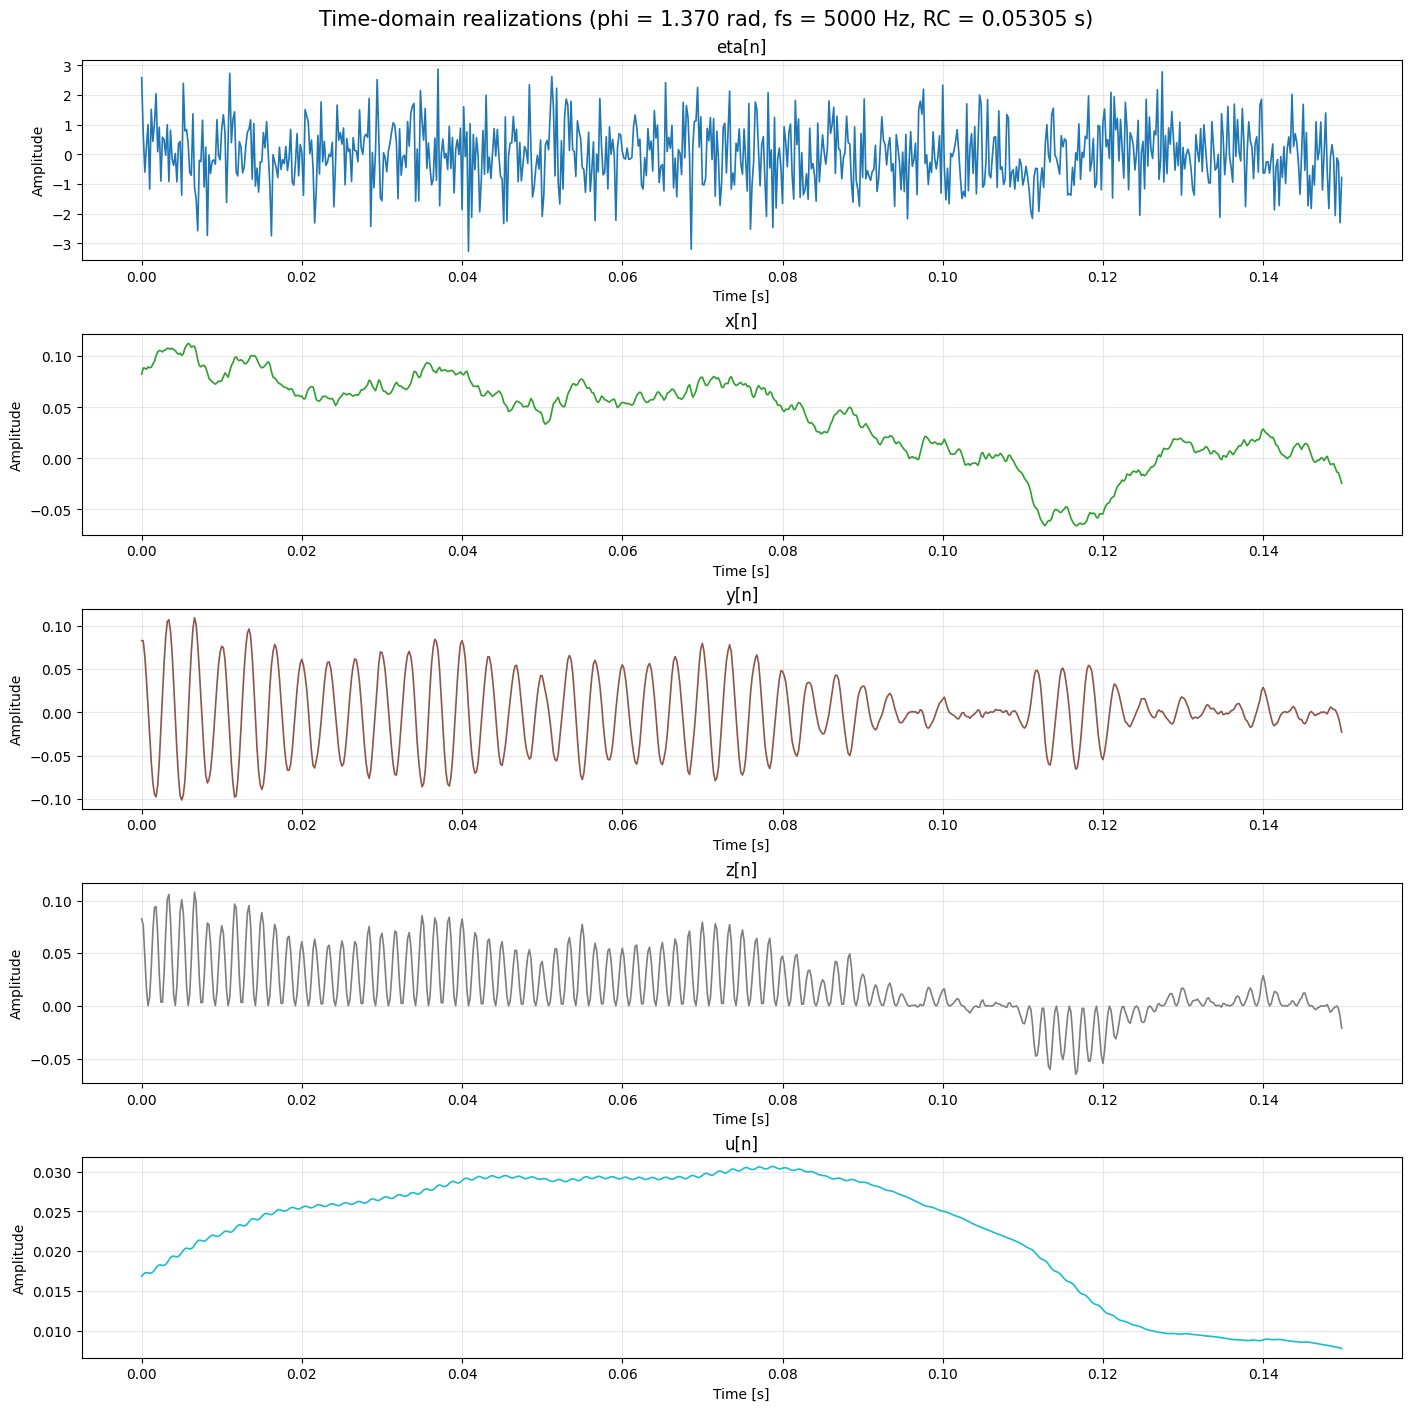

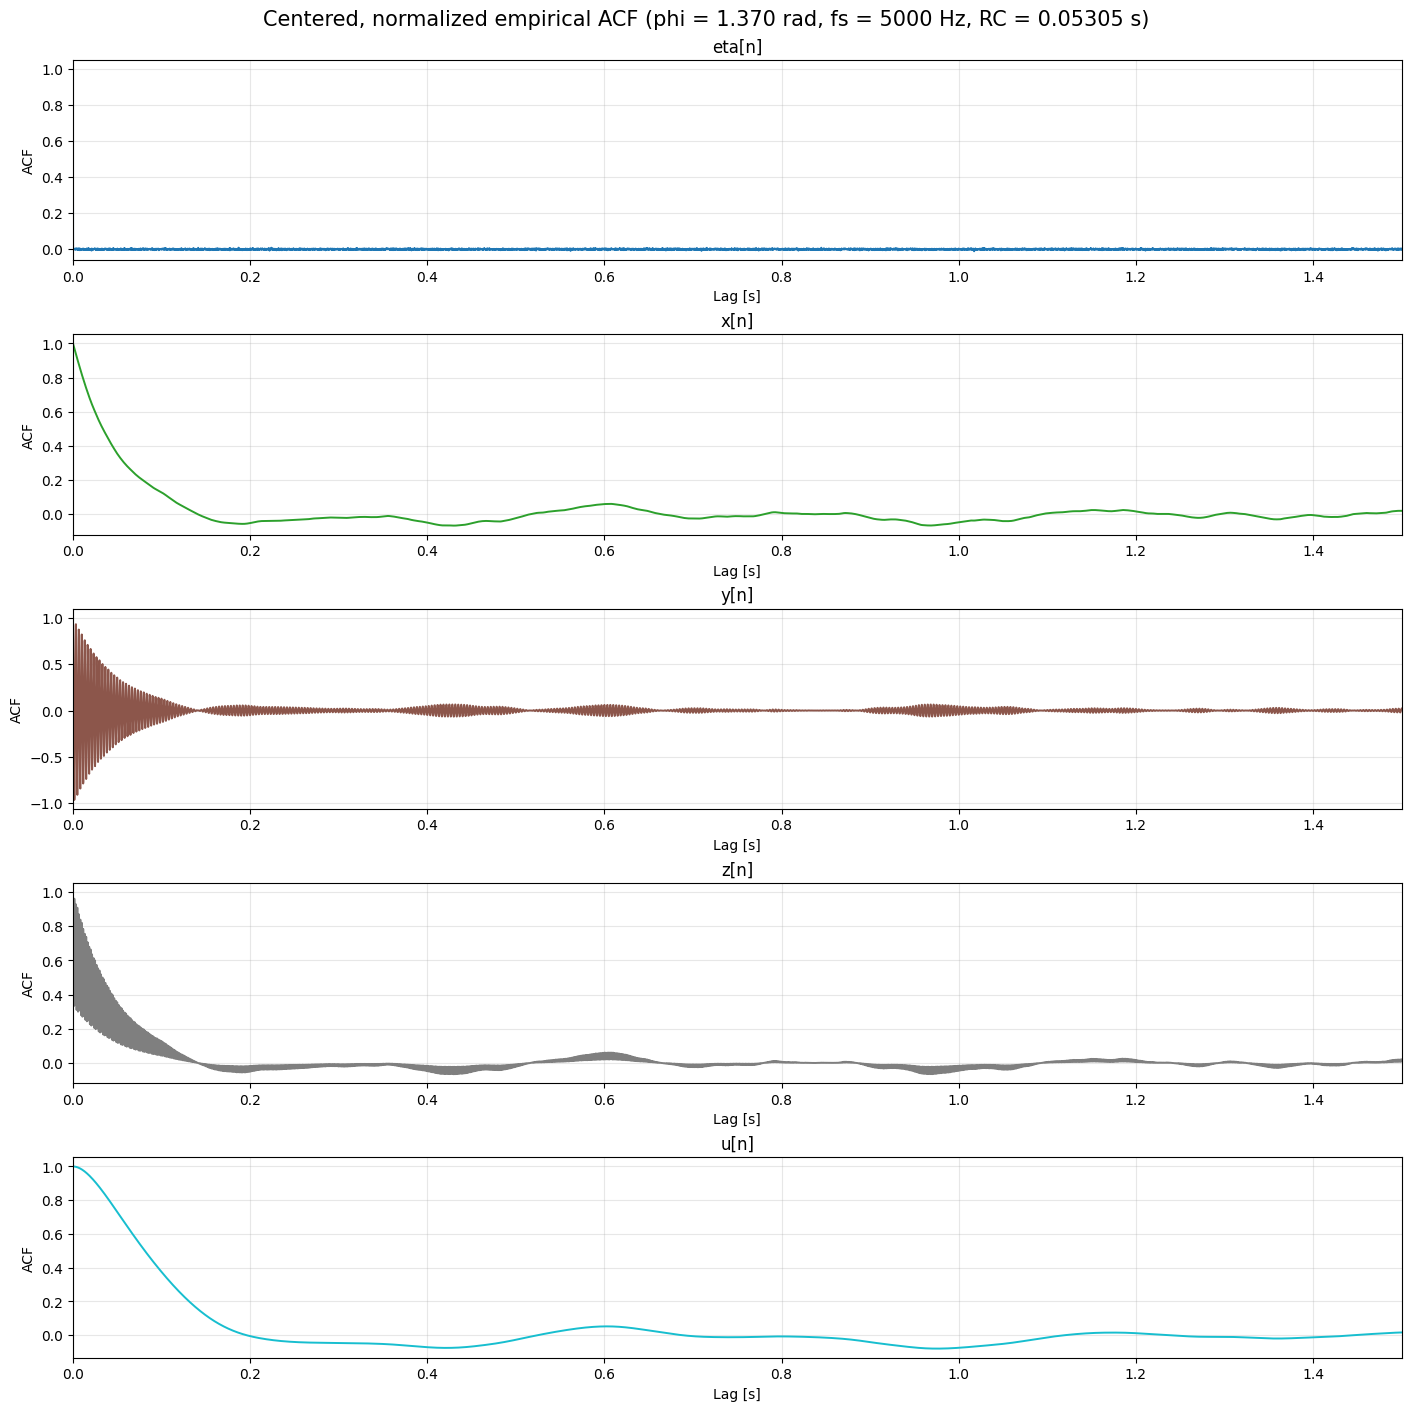

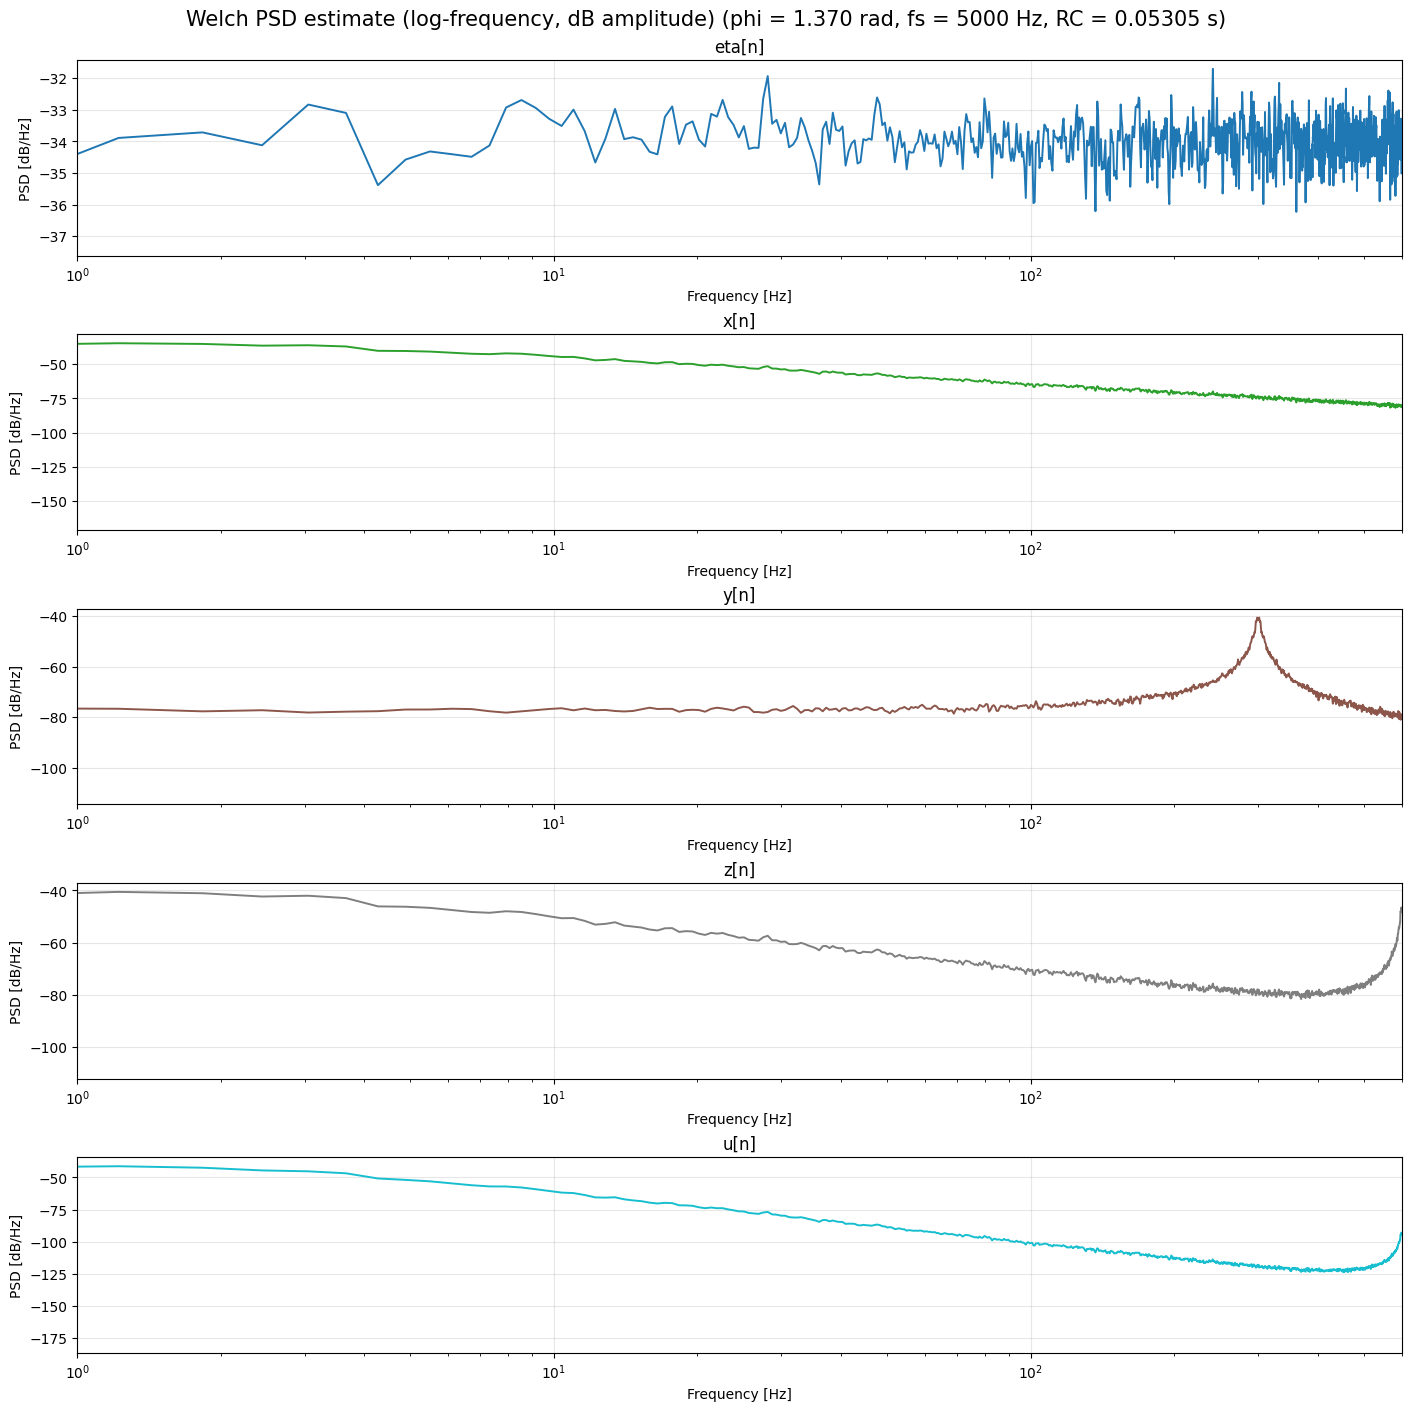

Sampled phi: 1.369766 rad
Carrier frequency: 300.0 Hz
RC cutoff frequency: 3.0 Hz
Saved time figure: /home/mitin/code/signal-theory/figures/modulation_assignment_time_realizations.png
Saved ACF figure: /home/mitin/code/signal-theory/figures/modulation_assignment_acfs.png
Saved PSD figure: /home/mitin/code/signal-theory/figures/modulation_assignment_psds.png


In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from scipy import signal

rng = np.random.default_rng(20260415)

# Assignment parameters
f = 3.0
Omega = 2 * np.pi * f
k = 100
omega_0 = k * Omega
f_0 = omega_0 / (2 * np.pi)

# RC low-pass parameters: same filter before and after demodulation
f_c = 3.0
RC = 1.0 / (2 * np.pi * f_c)

# Sampling and record configuration
fs = 5_000.0
Ts = 1.0 / fs
duration = 40.0
n_samples = int(duration * fs)
t = np.arange(n_samples) * Ts

# One random phase offset per realization
phi = rng.uniform(-np.pi, np.pi)

# Continuous-time RC filter H(s) = 1 / (1 + sRC), discretized by bilinear transform
b, a, _ = signal.cont2discrete(([1.0], [RC, 1.0]), Ts, method='bilinear')
b = np.squeeze(b)
a = np.squeeze(a)

# System simulation
eta = rng.standard_normal(n_samples)
x = signal.lfilter(b, a, eta)
carrier_tx = np.cos(omega_0 * t)
y = x * carrier_tx
carrier_rx = np.cos(omega_0 * t + phi)
z = y * carrier_rx
u = signal.lfilter(b, a, z)

# Discard startup transient from the RC filters before estimating statistics
transient_time = 2.0
trim = int(transient_time * fs)

stages = {
    'eta[n]': eta[trim:],
    'x[n]': x[trim:],
    'y[n]': y[trim:],
    'z[n]': z[trim:],
    'u[n]': u[trim:],
}

def normalized_acf(samples, fs, max_lag_s=1.5):
    centered = samples - np.mean(samples)
    corr = signal.correlate(centered, centered, mode='full', method='fft')
    mid = len(centered) - 1
    max_lag = int(max_lag_s * fs)
    acf = corr[mid:mid + max_lag + 1]
    acf /= acf[0]
    lags = np.arange(max_lag + 1) / fs
    return lags, acf

def welch_psd(samples, fs):
    nperseg = min(8192, len(samples))
    return signal.welch(samples, fs=fs, nperseg=nperseg, detrend='constant', scaling='density')

time_window_s = 0.15
time_window_n = int(time_window_s * fs)
time_axis = np.arange(time_window_n) / fs

candidate_dirs = [Path.cwd() / 'figures', Path.cwd().parent / 'figures']
output_dir = next((path for path in candidate_dirs if path.exists()), candidate_dirs[0])
output_dir.mkdir(exist_ok=True)

colors = plt.cm.tab10(np.linspace(0, 1, len(stages)))
stage_items = list(stages.items())

def make_domain_figure(title, x_label, y_label, x_limit=None, semilogx_db=False):
    fig, axes = plt.subplots(len(stage_items), 1, figsize=(14, 14), sharex=False, constrained_layout=True)
    fig.suptitle(
        title + f' (phi = {phi:.3f} rad, fs = {fs:.0f} Hz, RC = {RC:.5f} s)',
        fontsize=15,
    )
    for ax, color, (label, samples) in zip(np.atleast_1d(axes), colors, stage_items):
        if title.startswith('Time'):
            ax.plot(time_axis, samples[:time_window_n], lw=1.2, color=color)
        elif title.startswith('Centered'):
            lag_axis, acf = normalized_acf(samples, fs)
            ax.plot(lag_axis, acf, lw=1.4, color=color)
        else:
            freqs, psd = welch_psd(samples, fs)
            if semilogx_db:
                positive = freqs > 0
                psd_db = 10 * np.log10(psd[positive] + 1e-18)
                ax.semilogx(freqs[positive], psd_db, lw=1.4, color=color)
            else:
                ax.plot(freqs, psd, lw=1.4, color=color)
        ax.set_title(label)
        ax.set_xlabel(x_label)
        ax.set_ylabel(y_label)
        ax.grid(True, alpha=0.3)
        if x_limit is not None:
            ax.set_xlim(*x_limit)
    return fig

time_fig = make_domain_figure('Time-domain realizations', 'Time [s]', 'Amplitude')
acf_fig = make_domain_figure('Centered, normalized empirical ACF', 'Lag [s]', 'ACF', x_limit=(0.0, 1.5))
psd_fig = make_domain_figure('Welch PSD estimate (log-frequency, dB amplitude)', 'Frequency [Hz]', 'PSD [dB/Hz]', x_limit=(1.0, 600.0), semilogx_db=True)

time_path = output_dir / 'modulation_assignment_time_realizations.png'
acf_path = output_dir / 'modulation_assignment_acfs.png'
psd_path = output_dir / 'modulation_assignment_psds.png'

time_fig.savefig(time_path, dpi=180, bbox_inches='tight')
acf_fig.savefig(acf_path, dpi=180, bbox_inches='tight')
psd_fig.savefig(psd_path, dpi=180, bbox_inches='tight')

plt.show()

print(f'Sampled phi: {phi:.6f} rad')
print(f'Carrier frequency: {f_0:.1f} Hz')
print(f'RC cutoff frequency: {f_c:.1f} Hz')
print(f'Saved time figure: {time_path}')
print(f'Saved ACF figure: {acf_path}')
print(f'Saved PSD figure: {psd_path}')
